In [27]:
import os

print(os.getcwd())

c:\Users\Shrejal Mhatre\OneDrive\Desktop\Early-Disease-Risk-Prediction\data\raw


In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('default')

In [29]:
import os

for root, dirs, files in os.walk("../../"):
    for file in files:
        if "cardio" in file.lower():
            print(os.path.join(root, file))

../../notebooks\EDA.ipynb\cardio_data_processed.csv


In [30]:
import pandas as pd

df = pd.read_csv("../../notebooks/EDA.ipynb/cardio_data_processed.csv")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [31]:
import os
print(os.getcwd())

c:\Users\Shrejal Mhatre\OneDrive\Desktop\Early-Disease-Risk-Prediction\data\raw


In [32]:
print("Rows and Columns:", df.shape)

Rows and Columns: (68205, 17)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          68205 non-null 

In [34]:
df.isnull().sum()

id                     0
age                    0
gender                 0
height                 0
weight                 0
ap_hi                  0
ap_lo                  0
cholesterol            0
gluc                   0
smoke                  0
alco                   0
active                 0
cardio                 0
age_years              0
bmi                    0
bp_category            0
bp_category_encoded    0
dtype: int64

In [35]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [36]:
df['cardio'].value_counts()

cardio
0    34533
1    33672
Name: count, dtype: int64

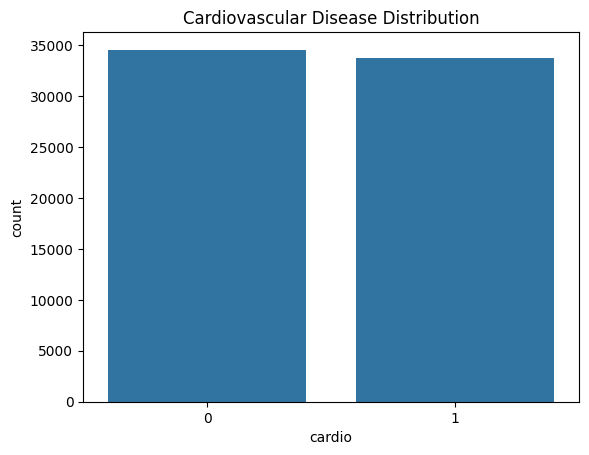

In [37]:
sns.countplot(x='cardio', data=df)

plt.title("Cardiovascular Disease Distribution")
plt.show()

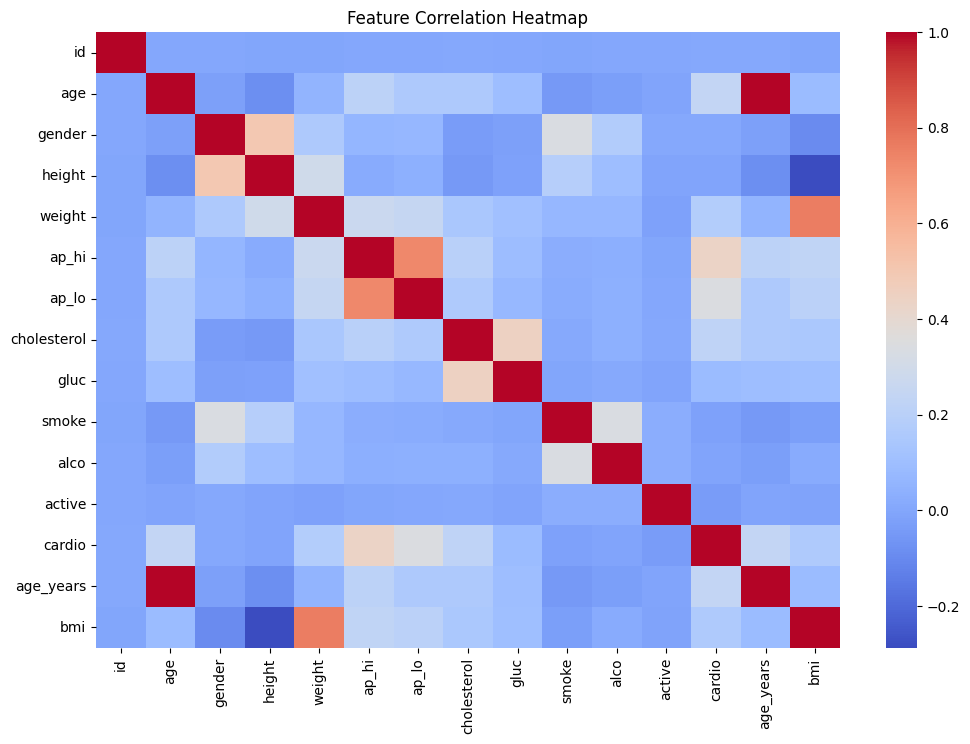

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

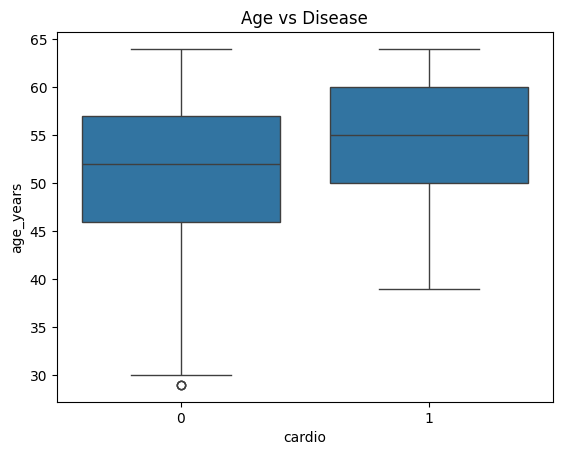

In [39]:
sns.boxplot(
    x='cardio',
    y='age_years',
    data=df
)

plt.title("Age vs Disease")
plt.show()

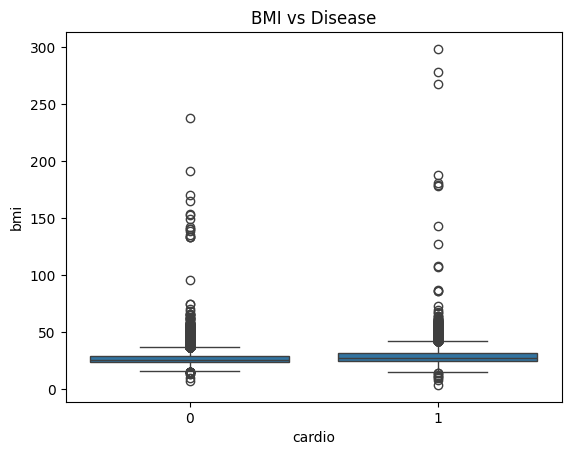

In [40]:
sns.boxplot(
    x='cardio',
    y='bmi',
    data=df
)

plt.title("BMI vs Disease")
plt.show()

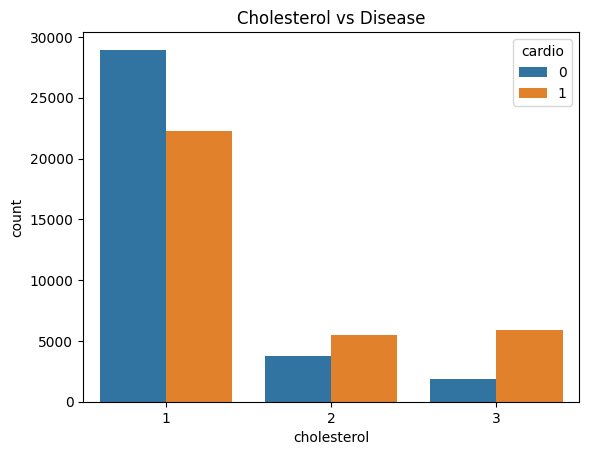

In [41]:
sns.countplot(
    x='cholesterol',
    hue='cardio',
    data=df
)

plt.title("Cholesterol vs Disease")
plt.show()

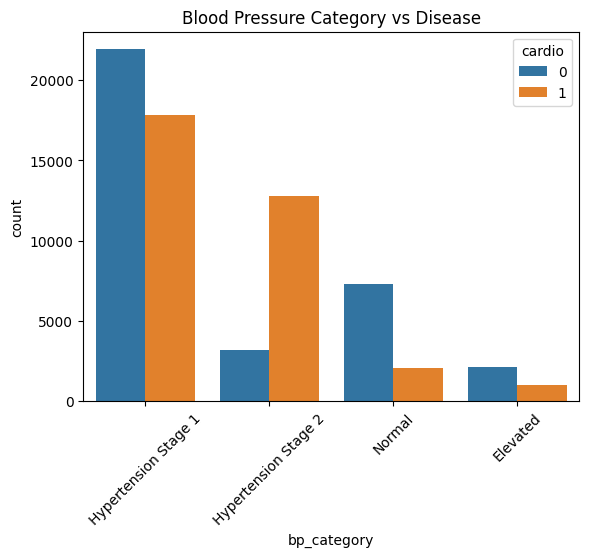

In [42]:
sns.countplot(
    x='bp_category',
    hue='cardio',
    data=df
)

plt.xticks(rotation=45)

plt.title("Blood Pressure Category vs Disease")
plt.show()

In [43]:
df['cardio'].value_counts(normalize=True) * 100

cardio
0    50.631185
1    49.368815
Name: proportion, dtype: float64

In [44]:
df = df.drop('id', axis=1)

In [45]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi',
       'bp_category', 'bp_category_encoded'],
      dtype='object')

In [46]:
print(df['bp_category'].unique())
print(df['bp_category_encoded'].unique())

['Hypertension Stage 1' 'Hypertension Stage 2' 'Normal' 'Elevated']
['Hypertension Stage 1' 'Hypertension Stage 2' 'Normal' 'Elevated']


In [47]:
X = df.drop('cardio', axis=1)

y = df['cardio']

In [48]:
print(X.shape)
print(y.shape)

(68205, 15)
(68205,)


In [49]:
X.dtypes

age                      int64
gender                   int64
height                   int64
weight                 float64
ap_hi                    int64
ap_lo                    int64
cholesterol              int64
gluc                     int64
smoke                    int64
alco                     int64
active                   int64
age_years                int64
bmi                    float64
bp_category             object
bp_category_encoded     object
dtype: object

In [50]:
X = pd.get_dummies(
    X,
    columns=['bp_category'],
    drop_first=True
)

In [51]:
X.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,bp_category_encoded,bp_category_Hypertension Stage 1,bp_category_Hypertension Stage 2,bp_category_Normal
0,18393,2,168,62.0,110,80,1,1,0,0,1,50,21.967120,Hypertension Stage 1,True,False,False
1,20228,1,156,85.0,140,90,3,1,0,0,1,55,34.927679,Hypertension Stage 2,False,True,False
2,18857,1,165,64.0,130,70,3,1,0,0,0,51,23.507805,Hypertension Stage 1,True,False,False
3,17623,2,169,82.0,150,100,1,1,0,0,1,48,28.710479,Hypertension Stage 2,False,True,False
4,17474,1,156,56.0,100,60,1,1,0,0,0,47,23.011177,Normal,False,False,True


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
print(df.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']


In [54]:
print(X_train.shape)
print(X_test.shape)

(54564, 17)
(13641, 17)


In [55]:
print(df.shape)

(68205, 16)


In [56]:
X = df.drop(columns=['cardio'])
y = df['cardio']

print(X.shape)
print(y.shape)

(68205, 15)
(68205,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']


In [58]:
print(X_train.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']


In [59]:
X_train.dtypes

age                      int64
gender                   int64
height                   int64
weight                 float64
ap_hi                    int64
ap_lo                    int64
cholesterol              int64
gluc                     int64
smoke                    int64
alco                     int64
active                   int64
age_years                int64
bmi                    float64
bp_category             object
bp_category_encoded     object
dtype: object

In [60]:
X_train.select_dtypes(include=['object']).columns

Index(['bp_category', 'bp_category_encoded'], dtype='object')

In [61]:
print(df['bp_category'].unique())
print(df['bp_category_encoded'].unique())

['Hypertension Stage 1' 'Hypertension Stage 2' 'Normal' 'Elevated']
['Hypertension Stage 1' 'Hypertension Stage 2' 'Normal' 'Elevated']


In [62]:
print(df['bp_category_encoded'].dtype)

object


In [63]:
print(df['bp_category_encoded'].head())

0    Hypertension Stage 1
1    Hypertension Stage 2
2    Hypertension Stage 1
3    Hypertension Stage 2
4                  Normal
Name: bp_category_encoded, dtype: object


In [64]:
print(df['bp_category_encoded'].unique()[:10])

['Hypertension Stage 1' 'Hypertension Stage 2' 'Normal' 'Elevated']


In [65]:
X_train.select_dtypes(include=['object']).columns

Index(['bp_category', 'bp_category_encoded'], dtype='object')

In [66]:
print(df[['bp_category','bp_category_encoded']].head())

            bp_category   bp_category_encoded
0  Hypertension Stage 1  Hypertension Stage 1
1  Hypertension Stage 2  Hypertension Stage 2
2  Hypertension Stage 1  Hypertension Stage 1
3  Hypertension Stage 2  Hypertension Stage 2
4                Normal                Normal


In [67]:
df = df.drop('bp_category_encoded', axis=1)

In [68]:
X = df.drop('cardio', axis=1)

X = pd.get_dummies(
    X,
    columns=['bp_category'],
    drop_first=True
)

y = df['cardio']

In [69]:
X.dtypes

age                                   int64
gender                                int64
height                                int64
weight                              float64
ap_hi                                 int64
ap_lo                                 int64
cholesterol                           int64
gluc                                  int64
smoke                                 int64
alco                                  int64
active                                int64
age_years                             int64
bmi                                 float64
bp_category_Hypertension Stage 1       bool
bp_category_Hypertension Stage 2       bool
bp_category_Normal                     bool
dtype: object

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [72]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [73]:
y_pred_lr = lr.predict(X_test_scaled)

In [74]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.7291254306868998


In [75]:
from sklearn.metrics import classification_report

In [76]:
print(y_pred_lr[:5])

[0 1 1 1 0]


In [77]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      0.80      0.75      6907
           1       0.76      0.65      0.70      6734

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641



In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:

y_pred_rf = rf.predict(X_test)

In [80]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7136573564987904


In [81]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      6907
           1       0.72      0.69      0.70      6734

    accuracy                           0.71     13641
   macro avg       0.71      0.71      0.71     13641
weighted avg       0.71      0.71      0.71     13641



In [82]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[5075 1832]
 [2074 4660]]


In [83]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 0.9998533831830511
Test Accuracy: 0.7136573564987904


In [84]:
## Tuned Random Forest

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score

print("Tuned RF Accuracy:",
      accuracy_score(y_test, y_pred_rf_tuned))

Tuned RF Accuracy: 0.7381423649292573


In [88]:
print("Train Accuracy:",
      rf_tuned.score(X_train, y_train))

print("Test Accuracy:",
      rf_tuned.score(X_test, y_test))

Train Accuracy: 0.7499450186936442
Test Accuracy: 0.7381423649292573


In [89]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,ap_hi,0.362232
5,ap_lo,0.132980
14,bp_category_Hypertension Stage 2,0.105792
0,age,0.092695
6,cholesterol,0.074432
11,age_years,0.066976
12,bmi,0.043168
3,weight,0.030415
15,bp_category_Normal,0.028670
2,height,0.019141


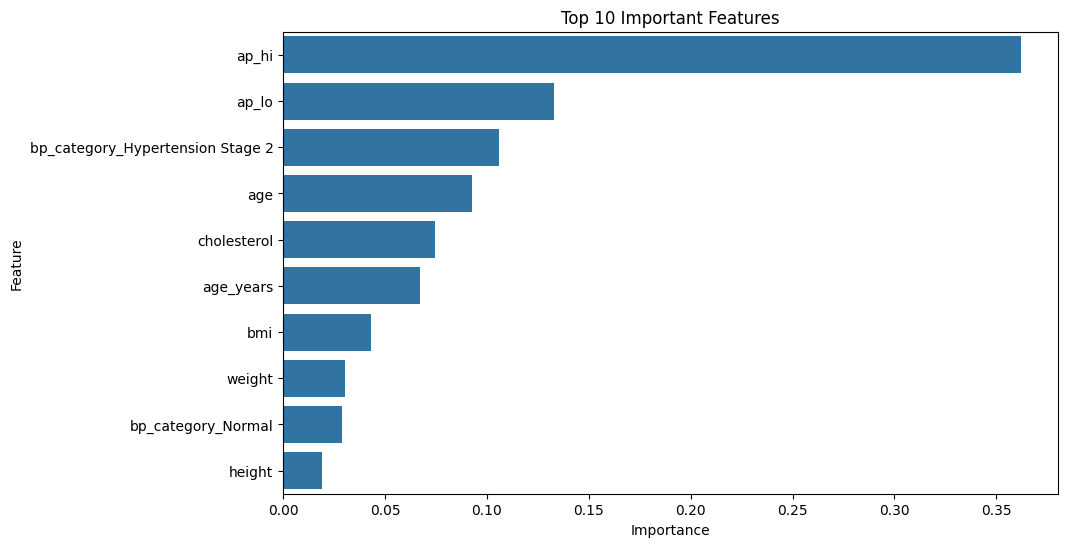

In [90]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features')
plt.show()

In [91]:
from xgboost import XGBClassifier

In [92]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [93]:
y_pred_xgb = xgb.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7388754490140019


In [95]:
print("Train Accuracy:",
      xgb.score(X_train, y_train))

print("Test Accuracy:",
      xgb.score(X_test, y_test))

Train Accuracy: 0.7485704860347482
Test Accuracy: 0.7388754490140019


In [96]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.729125
1,Tuned Random Forest,0.738142
2,XGBoost,0.738875


In [97]:
joblib.dump(
    xgb,
    "../../models/disease_prediction_model.pkl"
)

NameError: name 'joblib' is not defined

In [98]:
import os

print(os.listdir("../../models"))

['disease_prediction_model.pkl']
